In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import spacy
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
df = pd.read_csv(r"C:\Users\DeLL\Downloads\Combined Data.csv\Combined Data.csv")

In [3]:
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


### **Dropping unnecessary columns**

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


### **Summary of dataframe**

In [6]:
df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


### **Dealing with missing values**

In [8]:
df.isnull().sum()

statement    362
status         0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().any()

statement    False
status       False
dtype: bool

### **Dealing with Duplicate values**

In [11]:
# total number of duplicate values 

df.duplicated().sum()

np.int64(1588)

In [12]:
df = df.drop_duplicates(subset="statement")

In [13]:
df = df.reset_index(drop=True)

In [14]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [15]:
df.shape

(51073, 2)

### **Inspecting unique classes**

In [16]:
df["status"].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [17]:
#standardizing label names

df["status"] = df["status"].str.strip().str.title()

In [18]:
df["status"].value_counts()

status
Normal                  16039
Depression              15087
Suicidal                10641
Anxiety                  3617
Bipolar                  2501
Stress                   2293
Personality Disorder      895
Name: count, dtype: int64

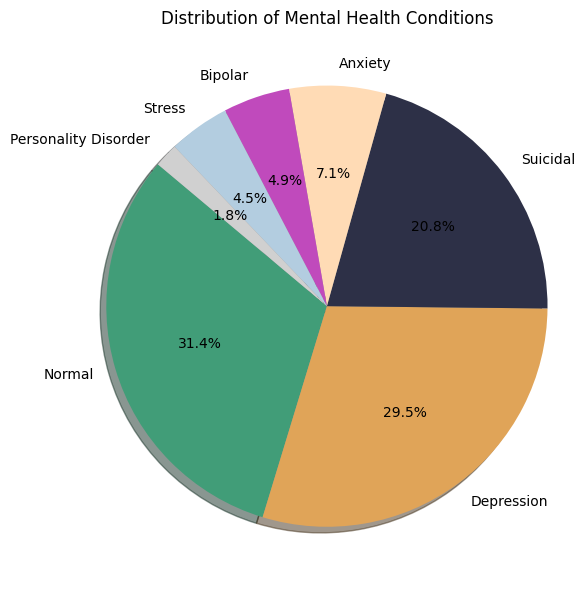

In [19]:
status_counts = df['status'].value_counts()

# Define colors for each category (7 colors)
colors = ['#419D78', '#E0A458', '#2D3047', '#FFDBB5', '#C04ABC', '#B3CDE0', '#D0D0D0']

# Create the pie chart
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, shadow=True)

plt.title('Distribution of Mental Health Conditions')
plt.axis('equal')  # Equal aspect ratio ensures that the pie is drawn as a circle.

# Display the chart
plt.tight_layout()
plt.show()

### **How long the statements are?**

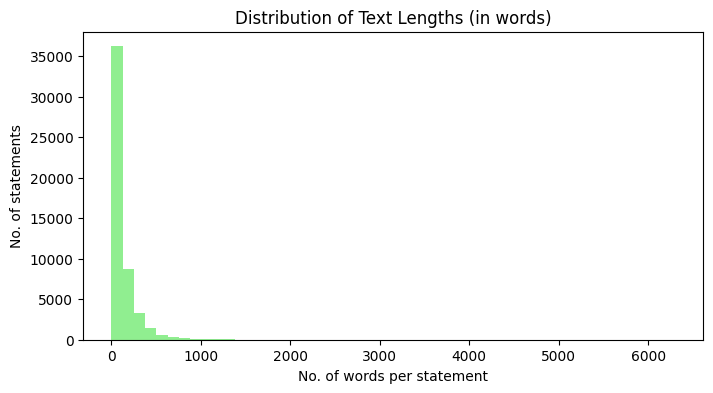

In [20]:
df['text_length'] = df['statement'].apply(lambda x: len(x.split()))

df['text_length'].describe()
plt.figure(figsize=(8,4))
plt.hist(df['text_length'], bins=50, color='lightgreen')
plt.title("Distribution of Text Lengths (in words)")
plt.xlabel("No. of words per statement")
plt.ylabel("No. of statements")
plt.show()

## **TEXT PREPROCESSING**

### basic cleaning

In [21]:
chatwords = {"ain't": "is not","isn t":"is not", "aren't": "are not","can't": "cannot","couldn't": "could not","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hasn't": "has not","haven't": "have not",
              "he's": "he is","she's": "she is","it's": "it is","that's": "that is","there's": "there is","what's": "what is","who's": "who is","I'm": "i am","i'm": "i am",
              "I'll": "i will","i'll": "i will","I'd": "i would","i'd": "i would","I've": "i have","i've": "i have","i ve":"i have", "isn't": "is not","let's": "let us",
              "shouldn't": "should not","won't": "will not","wouldn't": "would not","wasn't": "was not","weren't": "were not","you're": "you are","you've": "you have",
              "you'll": "you will","they're": "they are","they've": "they have","they'll": "they will","we're": "we are","we've": "we have","we'll": "we will","omg": "oh my god",
              "lol": "laughing out loud","lmao": "laughing my ass off","rofl": "rolling on the floor laughing","idk": "i do not know","imo": "in my opinion",
              "imho": "in my humble opinion","btw": "by the way","thx": "thanks","ty": "thank you","pls": "please","plz": "please","u": "you","ur": "your",
              "r": "are","ya": "you","wanna": "want to","gonna": "going to","gotta": "got to","kinda": "kind of","sorta": "sort of","lemme": "let me","gimme": "give me",
              "cuz": "because","bc": "because","bcoz": "because","bcz": "because","b4": "before","gr8": "great","l8r": "later","nvm": "never mind","tho": "though",
              "thx": "thanks","xoxo": "hugs and kisses","tbh": "to be honest","afaik": "as far as i know","asap": "as soon as possible","bff": "best friend forever",
              "brb": "be right back","fyi": "for your information","jk": "just kidding","np": "no problem","sry": "sorry","smh": "shaking my head","ttyl": "talk to you later",
              "wyd": "what are you doing","wtf": "what the fuck","wth": "what the hell","idc": "i do not care","ikr": "i know right","hbu": "how about you","ily": "i love you","luv": "love","n": "and",
              "coz": "because","bday": "birthday","msg": "message"}


In [22]:
def clean_text(text):
    text = text.lower()                                                      #lowercasing
    text = re.sub(r'https?:\/\/\S+', '', text)                               # remove urls
    text = re.sub(r'<.*?>', '', text)                                        # remove html tags
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)                               # remove @mentions
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)                               # remove hashtags
    text = text.replace('[', '').replace(']', '')                            # removing unnecessary brackets   
   
    text = re.sub(r'\d+', '', text)                                          # remove digits
    text = re.sub(r'\s+', ' ', text).strip()                                 # remove extra spaces
    text = text.replace("’", "'").replace("‘", "'")                          #normalizing apostrophe

    text = " ".join(chatwords.get(word, word) for word in text.split())      # expand chatwords
    text = re.sub(f"[{string.punctuation}]", " ", text)                      #removing punctuation after chatword exp
    
    return text


In [23]:
df["clean_text"] = df["statement"].apply(clean_text)

In [24]:
df.head()

,statement,status,text_length,clean_text
0,oh my gosh,Anxiety,3,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless hear...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,all wrong back off dear forward doubt stay ...
3,I've shifted my focus to something else but I'...,Anxiety,11,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",Anxiety,14,i am restless and restless it is been a month...


In [25]:
df_lstm = df[["statement","status","clean_text"]].copy()


## preserving this 'df' as 'df_lstm' for deep learning pipeline, because lstm does not really need lemmatization

### Lemmatization with spaCy

In [26]:
# !python -m spacy download en_core_web_sm

In [27]:
# !pip install spacy

In [28]:
import spacy

In [29]:
nlp = spacy.load("en_core_web_sm",disable=["ner","parser"])

In [30]:
texts = df["clean_text"].to_list()
docs = nlp.pipe(texts, batch_size=50)

In [31]:
df["lemmatized_text"] = [" ".join([token.lemma_ for token in doc]) for doc in docs]

In [32]:
df[["statement","lemmatized_text"]].sample(30)

,statement,lemmatized_text
9068,To every person who has ever said stuff along ...,to every person who have ever say stuff along ...
31321,i'm going to the bank.,I be go to the bank
8542,How do I kill myself in a country with no guns...,how do I kill myself in a country with no gun ...
49269,"Storytime... Hey, so... I've made some realiza...",storytime hey so I have make some re...
33546,a mad dog bit most of her face off.,a mad dog bit most of her face off
10288,Like I just do not want to feel like a sloth d...,like I just do not want to feel like a sloth d...
27704,After the 6 months we moved to a really big ho...,after the month we move to a really big house ...
13316,Sorry I am kind of ranting but I am really at ...,sorry I be kind of rant but I be really at my ...
33739,Always think I have cancer So I remember it st...,always think I have cancer so I remember it st...
1279,Hi! Buddy,hi buddy


## **Vectorization & Modelling**

In [33]:
x = df["lemmatized_text"]
y = df["status"]

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

In [35]:
tfidf = TfidfVectorizer(max_features=150000,
                        ngram_range=(1,3),
                        max_df=0.9,
                        min_df=5,
                        sublinear_tf = True)

In [36]:
xtrain_tfidf = tfidf.fit_transform(x_train)
xtest_tfidf = tfidf.transform(x_test)

### *LOGISTIC REGRESSION MODEL*

In [37]:
lr = LogisticRegression(C=5,
                           max_iter=10000,
                          class_weight="balanced",
                          solver="lbfgs",
                          multi_class = "multinomial")

In [38]:
scores = cross_val_score(lr, xtrain_tfidf, y_train, cv=5, scoring="f1_macro")

C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\

In [39]:
print("cv scores for each fold",scores)

cv scores for each fold [0.7079683  0.70179846 0.70932887 0.70821525 0.69658264]


In [40]:
print("mean cv score",scores.mean())

mean cv score 0.7047787030639336


In [41]:
print("st deviation",scores.std())

st deviation 0.004873286153054379


So, by looking at the mean we can say that the model gives a very fair and balanced performance and since the standard deviation is quite small which means the model's performance is stable and not overfitting at all.

In [42]:
lr.fit(xtrain_tfidf, y_train)

C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'multinomial'


In [43]:
ypred = lr.predict(xtest_tfidf)

In [44]:
print(classification_report(y_test, ypred))

                      precision    recall  f1-score   support

             Anxiety       0.78      0.82      0.80       723
             Bipolar       0.76      0.70      0.73       500
          Depression       0.72      0.66      0.69      3018
              Normal       0.90      0.93      0.91      3208
Personality Disorder       0.66      0.49      0.56       179
              Stress       0.53      0.56      0.54       459
            Suicidal       0.65      0.70      0.67      2128

            accuracy                           0.76     10215
           macro avg       0.71      0.69      0.70     10215
        weighted avg       0.76      0.76      0.76     10215



In [45]:
macro_f1 = f1_score(y_test, ypred, average="macro")

In [46]:
macro_f1

0.7017017660796573

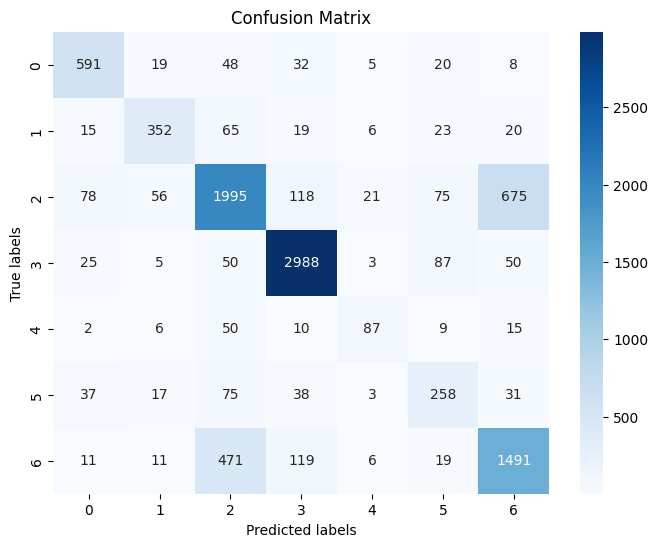

In [47]:
cm = confusion_matrix(y_test, ypred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

## **DEEP LEARNING PIPELINE with LSTM Model**

In [48]:
# pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [49]:
df_lstm.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless hear...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay ...
3,I've shifted my focus to something else but I'...,Anxiety,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",Anxiety,i am restless and restless it is been a month...


In [50]:
X = df_lstm["clean_text"]
Y = df_lstm["status"]

In [51]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y_encoded, test_size=0.2, random_state=42, stratify=Y)

In [53]:
## now we're gonna do tokenization (diff from ML pipeline), in order to convert text into numbers/sequence

max_vocab = 20000

tokenizer = Tokenizer(num_words=max_vocab,
                     oov_token = "<OOV>")

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [54]:
df_lstm["clean_text"].apply(lambda x:len(x.split())).describe()

count    51073.000000
mean       113.883402
std        165.375551
min          0.000000
25%         15.000000
50%         62.000000
75%        149.000000
max       6300.000000
Name: clean_text, dtype: float64

In [55]:
## padding squences, to make sure that the lstm model recieves equal length of sentences

max_len = 120     # bcx we have long sentences

X_train_pad = pad_sequences(X_train_seq,
                               maxlen = max_len,
                               padding='post',
                               truncating='post')

X_test_pad = pad_sequences(X_test_seq,
                               maxlen = max_len,
                               padding='post',
                               truncating='post')

In [56]:
# Now building LSTM model

model = Sequential()

# adding 1st layer as Embedding layer
model.add(Embedding(
    input_dim = 20000,
    output_dim = 128,
    input_shape = (120,)
))

# adding 2nd layer as LSTM layer
model.add(LSTM(64))

# adding 3rd layer as Dense layer
model.add(Dense(
    7,
    activation="softmax"
))

C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 120, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,609,863 (9.96 MB)

 Trainable params: 2,609,863 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = model.fit(
    X_train_pad,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - accuracy: 0.5113 - loss: 1.3212 - val_accuracy: 0.5732 - val_loss: 1.1158
Epoch 2/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - accuracy: 0.5959 - loss: 0.9941 - val_accuracy: 0.6222 - val_loss: 0.9059
Epoch 3/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 67s 65ms/step - accuracy: 0.6951 - loss: 0.7803 - val_accuracy: 0.7267 - val_loss: 0.7479
Epoch 4/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 68s 67ms/step - accuracy: 0.7865 - loss: 0.5856 - val_accuracy: 0.7319 - val_loss: 0.7432
Epoch 5/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/step - accuracy: 0.8398 - loss: 0.4607 - val_accuracy: 0.7329 - val_loss: 0.7684
Epoch 6/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 70s 69ms/step - accuracy: 0.8839 - loss: 0.3469 - val_accuracy: 0.7281 - val_loss: 0.8351
Epoch 7/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 71s 69ms/step - accuracy: 0.9159 - loss: 0.2590 - val_accuracy: 0.7198 - val_loss: 0.9108
Epoch 8/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 71s 69ms/step - accuracy: 0.9394 -

In [60]:
Y_pred = model.predict(X_test_pad)
Y_pred = np.argmax(Y_pred, axis=1)

320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


In [61]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.78      0.61      0.69       723
           1       0.72      0.65      0.68       500
           2       0.63      0.65      0.64      3018
           3       0.92      0.89      0.90      3208
           4       0.48      0.31      0.38       179
           5       0.33      0.44      0.38       459
           6       0.56      0.59      0.58      2128

    accuracy                           0.70     10215
   macro avg       0.63      0.59      0.61     10215
weighted avg       0.70      0.70      0.70     10215



In [62]:
macro_f1_score = f1_score(Y_test, Y_pred, average="macro")
print("macro_f1_score is", macro_f1_score)

macro_f1_score is 0.6065393010504402


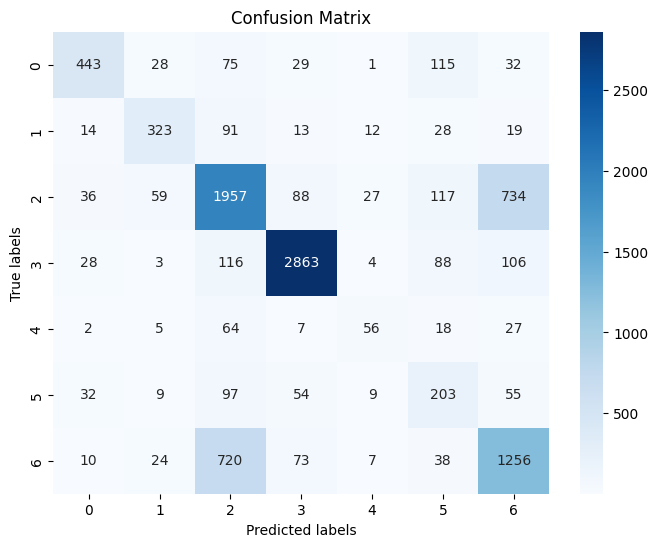

In [63]:
cm_ = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()